In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Coefficients for ax^3 + bx^2 + cx + d = 0
a, b, c, d = 1.0, -6.0, 11.0, -6.0   # Example: roots at x = 1, 2, 3
def cubic_function(x):
    return a * x**3 + b * x**2 + c * x + d

In [3]:
class CubicSolverNet(nn.Module):
    def __init__(self):
        super(CubicSolverNet, self).__init__()
        self.fc1 = nn.Linear(1, 16)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(16, 16)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x
model = CubicSolverNet()
print(model)

CubicSolverNet(
  (fc1): Linear(in_features=1, out_features=16, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=16, out_features=16, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=16, out_features=1, bias=True)
)


In [4]:
# We train the network to learn the mapping x -> f(x)
# Then use gradient descent on the trained model's input to find where f(x) = 0
x_train = torch.linspace(-10, 10, 500).view(-1, 1)
y_train = cubic_function(x_train)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
epochs = 2000
losses = []
for epoch in range(epochs):
    optimizer.zero_grad()
    output = model(x_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (epoch + 1) % 200 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [200/2000], Loss: 31490668794483046534994722816.0000
Epoch [400/2000], Loss: 13927810055372206413642203136.0000
Epoch [600/2000], Loss: 6160033109589893545851879424.0000
Epoch [800/2000], Loss: 2724475190109889592490459136.0000
Epoch [1000/2000], Loss: 1204989432003252146067734528.0000
Epoch [1200/2000], Loss: 532946174305627815406469120.0000
Epoch [1400/2000], Loss: 235712883155486198449831936.0000
Epoch [1600/2000], Loss: 104251654228733051845738496.0000
Epoch [1800/2000], Loss: 46108697500021262563409920.0000
Epoch [2000/2000], Loss: 20393078487670720116555776.0000


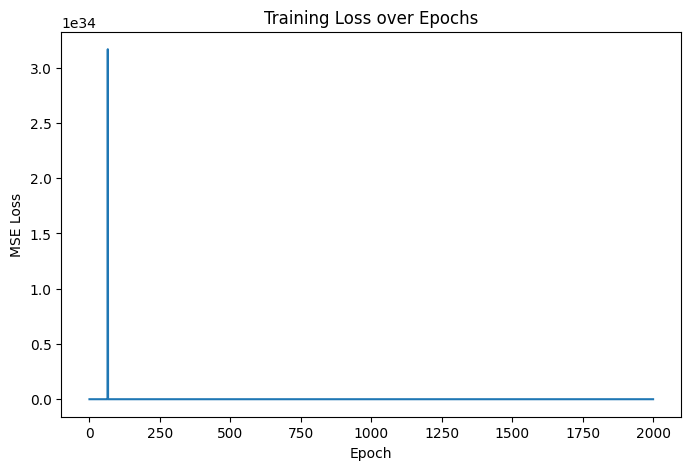

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss over Epochs")
plt.show()

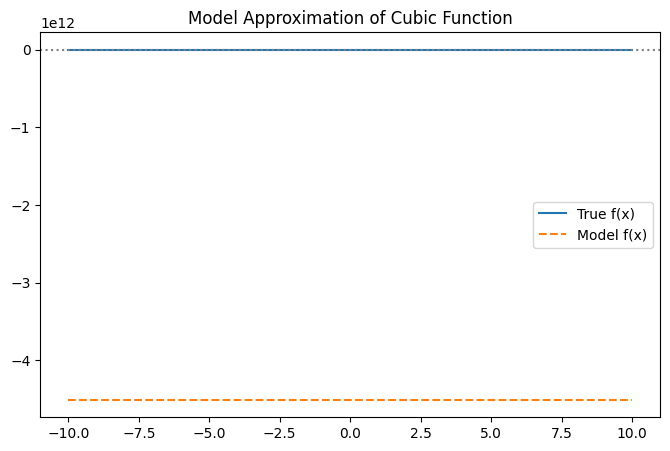

In [6]:
model.eval()
with torch.no_grad():
    y_pred = model(x_train)
plt.figure(figsize=(8, 5))
plt.plot(x_train.numpy(), y_train.numpy(), label="True f(x)")
plt.plot(x_train.numpy(), y_pred.numpy(), label="Model f(x)", linestyle="--")
plt.axhline(0, color='gray', linestyle=':')
plt.legend()
plt.title("Model Approximation of Cubic Function")
plt.show()

In [7]:
# Start from an initial guess and optimize x so that model(x) ≈ 0
x_root = torch.tensor([[0.0]], requires_grad=True)
root_optimizer = optim.SGD([x_root], lr=0.01, momentum=0.9)
root_epochs = 3000
for epoch in range(root_epochs):
    root_optimizer.zero_grad()
    output = model(x_root)
    loss = output.pow(2).mean()   # want f(x) -> 0
    loss.backward()
    root_optimizer.step()

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{root_epochs}], x = {x_root.item():.4f}, f(x) = {output.item():.4f}")
print(f"\nApproximate root found: x = {x_root.item():.4f}")
print(f"True f(x) at this root (using original equation): {cubic_function(x_root.item()):.4f}")

Epoch [500/3000], x = 0.0000, f(x) = -4506668498944.0000
Epoch [1000/3000], x = 0.0000, f(x) = -4506668498944.0000
Epoch [1500/3000], x = 0.0000, f(x) = -4506668498944.0000
Epoch [2000/3000], x = 0.0000, f(x) = -4506668498944.0000
Epoch [2500/3000], x = 0.0000, f(x) = -4506668498944.0000
Epoch [3000/3000], x = 0.0000, f(x) = -4506668498944.0000

Approximate root found: x = 0.0000
True f(x) at this root (using original equation): -6.0000


In [9]:
# Cubic equations can have up to 3 real roots — try multiple initial guesses
initial_guesses = [-5.0, 0.0, 5.0]
found_roots = []

for guess in initial_guesses:
    x_r = torch.tensor([[guess]], requires_grad=True)
    opt = optim.SGD([x_r], lr=0.01, momentum=0.9)

    for epoch in range(3000):
        opt.zero_grad()
        out = model(x_r)
        loss = out.pow(2).mean()
        loss.backward()
        opt.step()

    root_val = x_r.item()
    found_roots.append(root_val)
    print(f"Starting guess {guess} -> Root: {root_val:.4f}, f(root) = {cubic_function(root_val):.4f}")
print("\nAll approximate roots found:", [round(r, 4) for r in found_roots])

Starting guess -5.0 -> Root: -5.0000, f(root) = -336.0000
Starting guess 0.0 -> Root: 0.0000, f(root) = -6.0000
Starting guess 5.0 -> Root: 5.0000, f(root) = 24.0000

All approximate roots found: [-5.0, 0.0, 5.0]


In [10]:
# Sanity check using numpy's exact polynomial solver
coeffs = [a, b, c, d]
exact_roots = np.roots(coeffs)
print("Exact roots (NumPy):", exact_roots)
print("Model-found roots:", [round(r, 4) for r in found_roots])

Exact roots (NumPy): [3. 2. 1.]
Model-found roots: [-5.0, 0.0, 5.0]
